In [10]:
# Import library yang kalian butuhkan
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

In [11]:
data = []
labels = []
file_name = []

TARGET_SIZE = (128, 128)  # Ukuran seragam untuk semua citra

dataset_path = "dataset"

for sub_folder in sorted(os.listdir(dataset_path)):
    sub_folder_path = os.path.join(dataset_path, sub_folder)
    if not os.path.isdir(sub_folder_path):
        continue
    for filename in os.listdir(sub_folder_path):
        if not filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        img_path = os.path.join(sub_folder_path, filename)
        img = cv.imread(img_path)
        if img is None:
            continue
        img = cv.resize(img, TARGET_SIZE)
        img = img.astype(np.uint8)
        data.append(img)
        labels.append(sub_folder)
        file_name.append(filename)

data = np.array(data)
labels = np.array(labels)
print(f"Total data berhasil dimuat: {len(data)}")
print(f"Label unik: {np.unique(labels, return_counts=True)}")

Total data berhasil dimuat: 200
Label unik: (array(['fresh_bread', 'spoiled_bread'], dtype='<U13'), array([100, 100]))


=== Distribusi Data ===
  fresh_bread: 100 gambar
  spoiled_bread: 100 gambar
  Total: 200 gambar


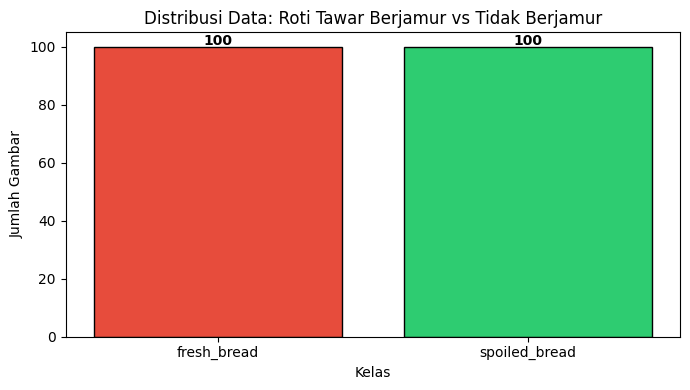

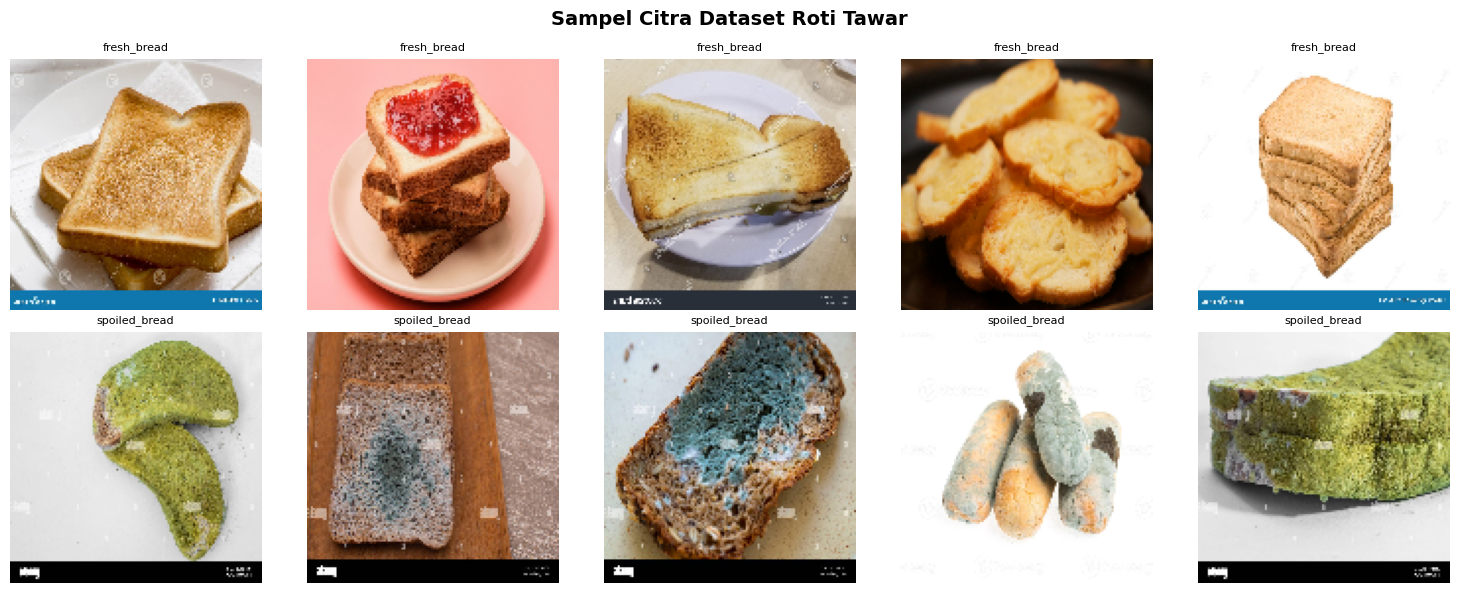

In [12]:
# Distribusi data per kelas
unique, counts = np.unique(labels, return_counts=True)
print("=== Distribusi Data ===")
for u, c in zip(unique, counts):
    print(f"  {u}: {c} gambar")
print(f"  Total: {len(labels)} gambar")

# Visualisasi distribusi
plt.figure(figsize=(7, 4))
plt.bar(unique, counts, color=['#e74c3c', '#2ecc71'], edgecolor='black')
plt.title('Distribusi Data: Roti Tawar Berjamur vs Tidak Berjamur')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Gambar')
for i, (u, c) in enumerate(zip(unique, counts)):
    plt.text(i, c + 0.5, str(c), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Tampilkan sampel citra dari masing-masing kelas
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sampel Citra Dataset Roti Tawar', fontsize=14, fontweight='bold')
for idx, kelas in enumerate(unique):
    indices = np.where(labels == kelas)[0]
    for j in range(5):
        img_bgr = data[indices[j]]
        img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
        axes[idx][j].imshow(img_rgb)
        axes[idx][j].set_title(kelas, fontsize=8)
        axes[idx][j].axis('off')
plt.tight_layout()
plt.show()

In [13]:
# Cek apakah augmentasi diperlukan
MIN_SAMPLES = 70
unique_cls, counts_cls = np.unique(labels, return_counts=True)
needs_aug = any(c < MIN_SAMPLES for c in counts_cls)

data_augmented = list(data.copy())
labels_augmented = list(labels.copy())
file_name_augmented = list(file_name.copy())

if needs_aug:
    print("Data kurang dari batas minimum, melakukan augmentasi...")
    for i in range(len(data)):
        img = data[i]
        lbl = labels[i]
        fname = file_name[i]
        # Flip horizontal
        flipped = cv.flip(img, 1)
        data_augmented.append(flipped)
        labels_augmented.append(lbl)
        file_name_augmented.append("aug_flip_" + fname)
        # Rotasi 90 derajat
        rotated = cv.rotate(img, cv.ROTATE_90_CLOCKWISE)
        data_augmented.append(rotated)
        labels_augmented.append(lbl)
        file_name_augmented.append("aug_rot90_" + fname)
    print(f"Data sebelum augmentasi: {len(data)}")
    print(f"Data setelah augmentasi : {len(data_augmented)}")
else:
    print("Data sudah mencukupi, augmentasi tidak diperlukan.")
    print(f"Total data: {len(data_augmented)}")

data_augmented = np.array(data_augmented)
labels_augmented = np.array(labels_augmented)
file_name_augmented = np.array(file_name_augmented)

Data sudah mencukupi, augmentasi tidak diperlukan.
Total data: 200


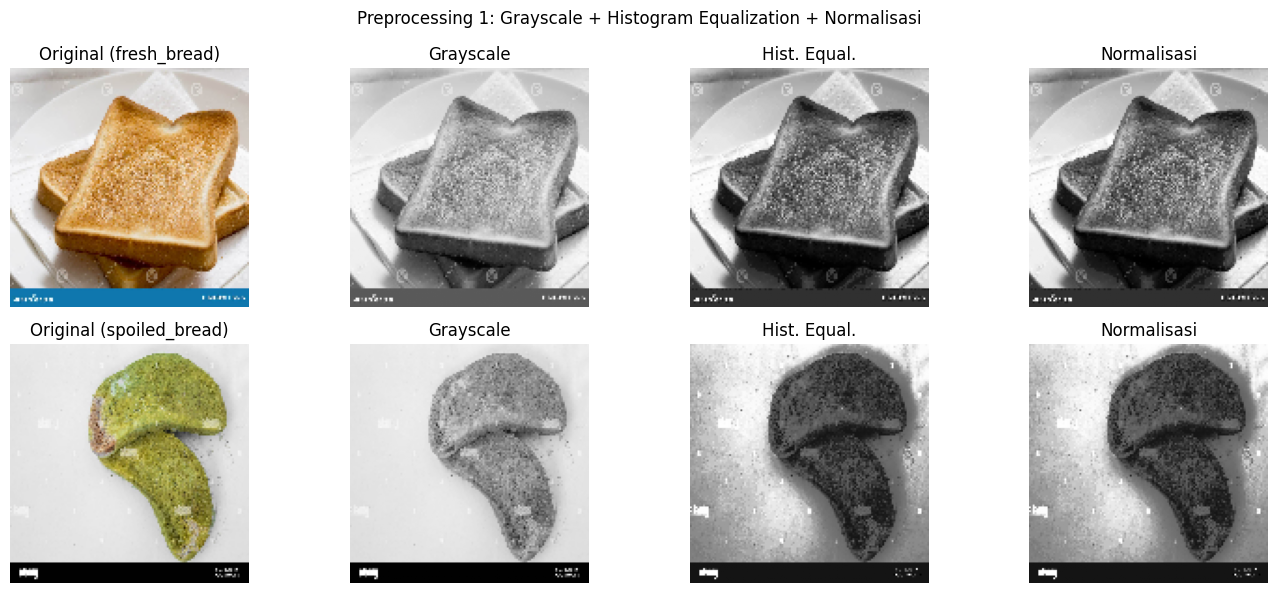

In [14]:
def prepro1(image):
    """
    Preprocessing 1: Grayscale + Histogram Equalization + Normalisasi
    - Grayscale     : menyederhanakan data menjadi 1 channel
    - Hist. Equal.  : meningkatkan kontras agar perbedaan area berjamur vs
                      tidak berjamur lebih terlihat (terutama citra kurang terang)
    - Normalisasi   : menyeragamkan rentang nilai piksel ke [0,1]
    """
    if len(image.shape) == 3:
        gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    else:
        gray = image.copy()
    equalized   = cv.equalizeHist(gray)
    normalized  = equalized.astype(np.float32) / 255.0
    # Kembalikan ke uint8 untuk kompatibilitas GLCM
    result = (normalized * 255).astype(np.uint8)
    return result

# Preview hasil preprocessing
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle('Preprocessing 1: Grayscale + Histogram Equalization + Normalisasi', fontsize=12)
for idx, kelas in enumerate(np.unique(labels)):
    sample_idx = np.where(labels == kelas)[0][0]
    img_ori  = data[sample_idx]
    img_pre  = prepro1(img_ori)
    axes[idx][0].imshow(cv.cvtColor(img_ori, cv.COLOR_BGR2RGB)); axes[idx][0].set_title(f'Original ({kelas})'); axes[idx][0].axis('off')
    axes[idx][1].imshow(cv.cvtColor(img_ori, cv.COLOR_BGR2GRAY), cmap='gray'); axes[idx][1].set_title('Grayscale'); axes[idx][1].axis('off')
    axes[idx][2].imshow(cv.equalizeHist(cv.cvtColor(img_ori, cv.COLOR_BGR2GRAY)), cmap='gray'); axes[idx][2].set_title('Hist. Equal.'); axes[idx][2].axis('off')
    axes[idx][3].imshow(img_pre, cmap='gray'); axes[idx][3].set_title('Normalisasi'); axes[idx][3].axis('off')
plt.tight_layout()
plt.show()

In [15]:
# Percobaan 1: hanya menggunakan Prepro 1
dataPreprocessed = []
for i in range(len(data_augmented)):
    hasil = prepro1(data_augmented[i])
    dataPreprocessed.append(hasil)
dataPreprocessed = np.array(dataPreprocessed)
print(f"Total citra setelah preprocessing: {len(dataPreprocessed)}")

Total citra setelah preprocessing: 200


In [16]:
def extract_glcm_features(image, distances=[1, 2, 3, 4, 5]):
    """
    Ekstraksi fitur GLCM dari citra grayscale.
    Sudut: 0, 45, 90, 135 derajat | Simetris | Distance 1-5
    Fitur: Contrast, Dissimilarity, Homogeneity, Energy, Correlation, Entropy, ASM
    """
    angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
    angle_names = ['0', '45', '90', '135']
    feature_names_base = ['Contrast', 'Dissimilarity', 'Homogeneity', 'Energy', 'Correlation', 'ASM', 'Entropy']
    
    features = {}
    
    for dist in distances:
        glcm_mat = graycomatrix(image, distances=[dist], angles=angles,
                                levels=256, symmetric=True, normed=True)
        for ai, ang_name in enumerate(angle_names):
            g = glcm_mat[:, :, 0:1, ai:ai+1]
            features[f'Contrast_d{dist}_a{ang_name}']     = graycoprops(g, 'contrast')[0, 0]
            features[f'Dissimilarity_d{dist}_a{ang_name}'] = graycoprops(g, 'dissimilarity')[0, 0]
            features[f'Homogeneity_d{dist}_a{ang_name}']  = graycoprops(g, 'homogeneity')[0, 0]
            features[f'Energy_d{dist}_a{ang_name}']       = graycoprops(g, 'energy')[0, 0]
            features[f'Correlation_d{dist}_a{ang_name}']  = graycoprops(g, 'correlation')[0, 0]
            features[f'ASM_d{dist}_a{ang_name}']          = graycoprops(g, 'ASM')[0, 0]
            features[f'Entropy_d{dist}_a{ang_name}']      = sp_entropy(glcm_mat[:, :, 0, ai].ravel())
    return features

print("Fungsi GLCM siap digunakan!")

Fungsi GLCM siap digunakan!


In [17]:
print("Memulai ekstraksi fitur GLCM...")
all_features = []
for i, img in enumerate(dataPreprocessed):
    feats = extract_glcm_features(img, distances=[1, 2, 3, 4, 5])
    feats['Filename'] = file_name_augmented[i]
    feats['Label']    = labels_augmented[i]
    all_features.append(feats)
    if (i+1) % 10 == 0:
        print(f"  Diproses: {i+1}/{len(dataPreprocessed)}")

df = pd.DataFrame(all_features)
df.to_csv('hasil_ekstraksi_percobaan1.csv', index=False)
hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan1.csv')
print(f"\nEkstraksi selesai! Shape: {hasilEkstrak.shape}")
hasilEkstrak.head()

Memulai ekstraksi fitur GLCM...


NameError: name 'sp_entropy' is not defined